# Show cases Testing with Concept Activation Vectors (TCAV) on Imagenet Dataset and GoogleNet model
# 展示案例：在 ImageNet 数据集和 GoogleNet 模型上使用概念激活向量 (TCAV) 进行测试

This tutorial shows how to apply TCAV, a concept-based model interpretability algorithm, on a classification task using GoogleNet model and imagenet dataset.

More details about the approach can be found here:
https://arxiv.org/pdf/1711.11279.pdf

In order to use TCAV, we need to predefine a list of concepts that we want our predictions to be test against.

**Concepts** are human-understandable, high-level abstractions such as visually represented "stripes" in case of images or tokens such as "female" in case of text. Concepts are formatted and represented as input tensors and do not need to be part of the training or test datasets.

Concepts are incorporated into the importance score computations using Concept Activation Vectors (CAVs). Traditionally, CAVs train linear classifiers and learn decision boundaries between different concepts using the activations of predefined concepts in a NN layer as inputs to the classifier that we train. The vector that is orthogonal to learnt decision boundary and is pointing towards the direction of a concept is the CAV of that concept.

TCAV measures the importance of a concept for a prediction based on the directional sensitivity (derivatives) of a concept in Neural Network (NN) layers. For a given concept and layer it is obtained by **aggregating** the dot product between CAV for a given concept in a given layer and the gradients of model predictions w.r.t. given layer output. The aggregation can be performed based on either signs or magnitudes of the directional sensitivities of concepts across multiple examples belonging to a certain class. More details about the technique can be found in above mentioned papers.

**Note:** Before running this tutorial, please install the torchvision, numpy, scipy, sklearn, PIL, and matplotlib packages.


本教程展示了如何将基于概念的模型可解释性算法 TCAV 应用于使用 GoogleNet 模型和 ImageNet 数据集的分类任务。

有关该方法的更多详细信息，请参见此处： https://arxiv.org/pdf/1711.11279.pdf

为了使用 TCAV，我们需要预先定义一个概念列表，以便对我们的预测进行测试。

概念是人类可以理解的高级抽象概念，例如图像中的“条纹”或文本中的“女性”等视觉表示。概念以输入张量的形式格式化和表示，无需包含在训练集或测试集中。

概念通过概念激活向量（CAV）融入重要性评分的计算中。传统上，CAV 训练线性分类器，并利用神经网络层中预定义概念的激活值作为输入，学习不同概念之间的决策边界。与学习到的决策边界正交且指向某个概念方向的向量，即为该概念的 CAV。

TCAV 衡量概念在神经网络 (NN) 层中对预测的重要性，其依据是概念的方向敏感性（导数）。对于给定的概念和层，TCAV 的计算方法是：将该概念在给定层中的 CAV 值与模型预测值相对于该层输出的梯度进行点积聚合。聚合过程可以基于同一类别中多个示例的概念方向敏感性的符号或大小进行。有关该技术的更多细节，请参阅上述论文。

注意：在运行本教程之前，请安装 torchvision、numpy、scipy、sklearn、PIL 和 matplotlib 软件包。

In [19]:
import numpy as np
import os, glob

import matplotlib.pyplot as plt

from PIL import Image

from scipy.stats import ttest_ind

# ..........torch imports............
import torch
import torchvision

from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms

#.... Captum imports..................
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients

from captum.concept import TCAV
from captum.concept import Concept

from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str


## Defining image related transformations and functions
## 定义图像相关变换和函数

Let's define image transformation function.

让我们定义图像变换函数。

In [20]:
# Method to normalize an image to Imagenet mean and standard deviation
def transform(img):

    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
        ]
    )(img)


Now let's define a few helper functions.

现在我们来定义一些辅助函数。

In [21]:
def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("RGB")
    return transform(img)


def load_image_tensors(class_name, root_path='data/tcav/image/imagenet/', transform=True):
    path = os.path.join(root_path, class_name)
    filenames = glob.glob(path + '/*.jpg')

    tensors = []
    for filename in filenames:
        img = Image.open(filename).convert('RGB')
        tensors.append(transform(img) if transform else img)
    
    return tensors


Defining a helper function to load predefined concepts. `assemble_concept` function reads the concepts using a directory path where the concepts are residing and constructs concept object.

定义一个辅助函数来加载预定义的概念。assemble_concept该函数使用概念所在的目录路径读取概念，并构建概念对象。

In [22]:
def assemble_concept(name, id, concepts_path="data/tcav/image/concepts/"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)

    return Concept(id=id, name=name, data_iter=concept_iter)


Let's assemble concepts into Concept instances using Concept class and concept images stored in `concepts_path`. We will use these concepts later in our experiments. 
Below we define five concepts. Three out of five are related to image texture and patterns such as `striped`, `zigzagged` and `dotted`. The other two represent random concepts. Random concepts contain elements / images that are associated with various possible concepts. Distinct from those defined for `striped`, `zigzagged` and `dotted`.

Note that concepts should be created and stored under `data/tcav/image/concepts/` folder in advance. 

`striped`, `zigzagged` and `dotted` concepts can be found in broden dataset:  https://netdissect.csail.mit.edu/broden1_224, under `images/dtd` folder as also described here: https://github.com/tensorflow/tcav/tree/master/tcav/tcav_examples/image_models/imagenet. There are in total 120 images for each of the `striped`, `zigzagged` and `dotted` concepts.

Please, download those concept images and place under `striped`, `zigzagged` and `dotted` folders under `data/tcav/image/concepts/` folder accordingly.

Random type of concepts are uniformly sampled from imagenet dataset. More details on how to download and setup imagenet dataset can he found here:
https://github.com/tensorflow/tcav/tree/master/tcav/tcav_examples/image_models/imagenet

We will randomly sample 4 diffent sets of 120 random images from imagenet dataset. Note that these images should be distinct from concept and zebra images since the testing will be performed on zebra images.
Place random images under `random_0`, `random_1`, `random_2` and `random_3` folders under `data/tcav/image/concepts/` folder similar to `striped` concept.


In [23]:
concepts_path = "data/tcav/image/concepts/"

stripes_concept = assemble_concept("striped", 0, concepts_path=concepts_path)
zigzagged_concept = assemble_concept("zigzagged", 1, concepts_path=concepts_path)
dotted_concept = assemble_concept("dotted", 2, concepts_path=concepts_path)


random_0_concept = assemble_concept("random_0", 3, concepts_path=concepts_path)
random_1_concept = assemble_concept("random_1", 4, concepts_path=concepts_path)

Let\'s visualize some samples from those concepts

让我们通过一些例子来理解这些概念。

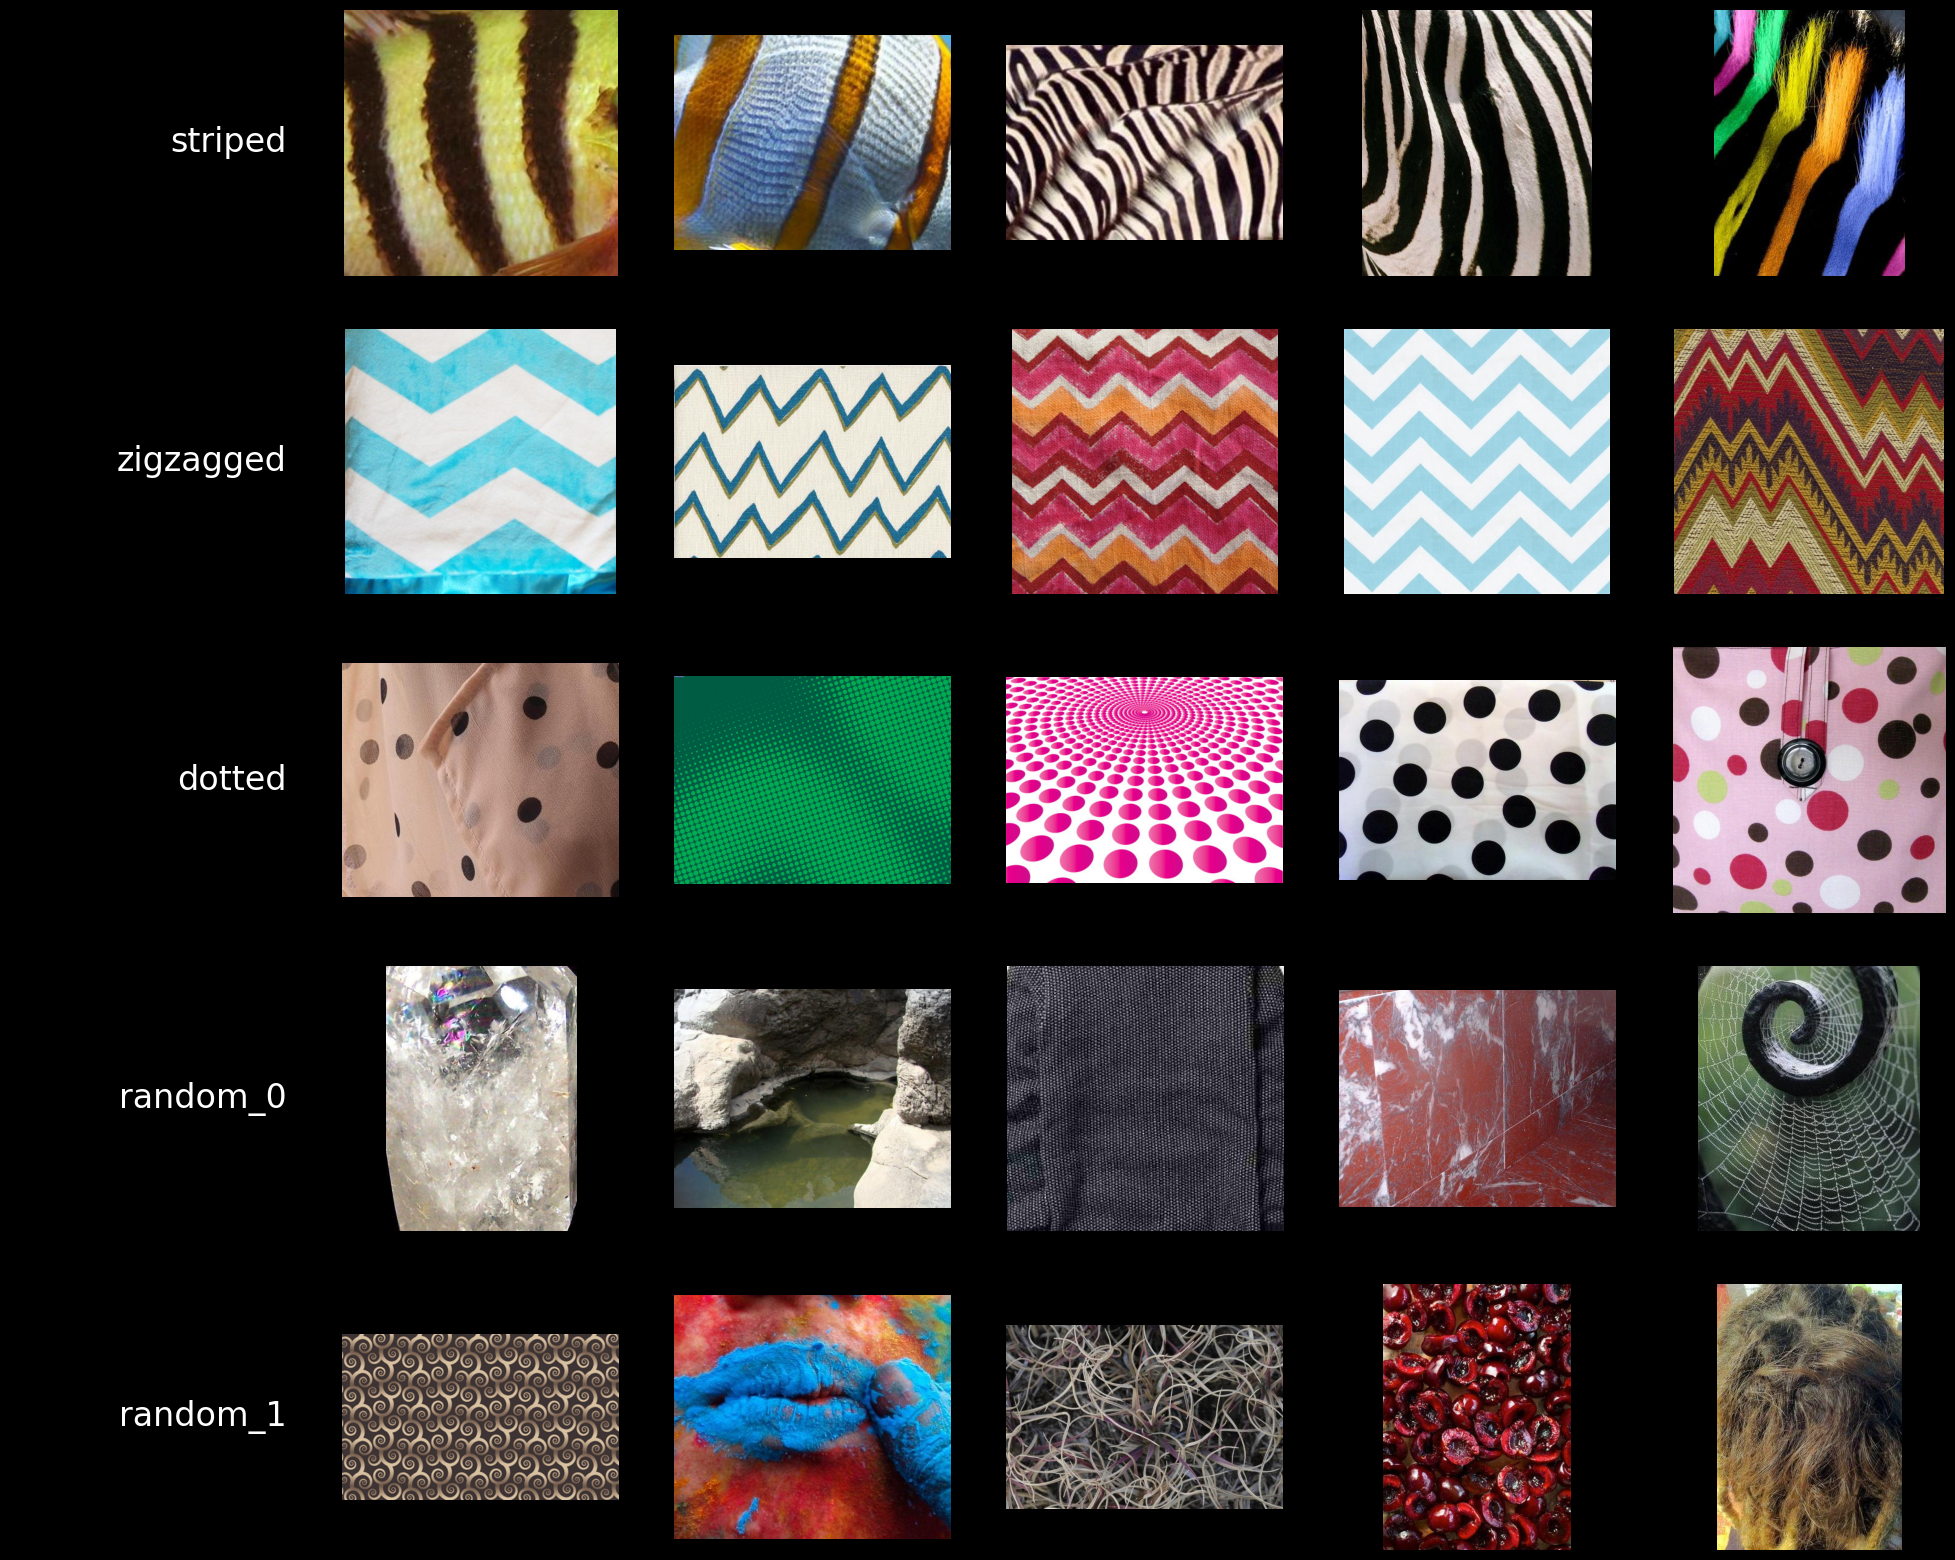

In [24]:
n_figs = 5
n_concepts = 5

fig, axs = plt.subplots(n_concepts, n_figs + 1, figsize = (25, 4 * n_concepts))

for c, concept in enumerate([stripes_concept, zigzagged_concept, dotted_concept, random_0_concept, random_1_concept]):
    concept_path = os.path.join(concepts_path, concept.name) + "/"
    img_files = glob.glob(concept_path + '*')
    for i, img_file in enumerate(img_files[:n_figs + 1]):
        if os.path.isfile(img_file):
            if i == 0:
                axs[c, i].text(1.0, 0.5, str(concept.name), ha='right', va='center', family='sans-serif', size=24)
            else:
                img = plt.imread(img_file)
                axs[c, i].imshow(img)

            axs[c, i].axis('off')


## Defining GoogleNet Model
## 定义 GoogleNet 模型

For this tutorial, we will load GoogleNet model and set in eval mode.

在本教程中，我们将加载 GoogleNet 模型并将其设置为评估模式。

In [25]:
model = torchvision.models.googlenet(pretrained=True)
model = model.eval()

# Computing TCAV Scores
# 计算 TCAV 分数

Next, let's create TCAV class by passing the instance of GoogleNet model, a custom classifier and the list of layers where we would like to test the importance of concepts.

接下来，让我们通过传入 GoogleNet 模型实例、自定义分类器以及我们想要测试概念重要性的层列表来创建 TCAV 类。

The custom classifier will be trained to learn classification boundaries between concepts. We offer a default implementation of Custom Classifier in captum library so that the users do not need to define it. Captum users, hoowever, are welcome to define their own classifers with any custom logic. CustomClassifier class extends abstract Classifier class and provides implementations for training workflow for the classifier and means to access trained weights and classes. Typically, this can be, but is not limited to a classier, from sklearn library. In this case CustomClassifier wraps `linear_model.SGDClassifier` algorithm from sklearn library.

自定义分类器将经过训练，学习概念之间的分类边界。我们在 Captum 库中提供了一个默认的自定义分类器实现，用户无需自行定义。当然，Captum 用户也可以使用任何自定义逻辑定义自己的分类器。CustomClassifier 类继承自抽象的 Classifier 类，并提供了分类器训练工作流程的实现，以及访问已训练权重和类别的方法。通常，这可以是（但不限于）来自 sklearn 库的分类器。在本例中，CustomClassifier 封装了linear_model.SGDClassifiersklearn 库中的算法。

In [26]:
layers=['inception4c', 'inception4d', 'inception4e']

mytcav = TCAV(model=model,
              layers=layers,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))


##### Defining experimantal sets for CAV

##### 定义 CAV 的实验集

Then, lets create 2 experimental sets: ["striped", "random_0"] and ["striped", "random_1"].

We will train a classifier for each experimal set that learns hyperplanes which separate the concepts in each experimental set from one another. This is especially interesting when later we want to perform two-sided statistical significance testing in order to confirm or reject the significance of a concept in a specific layer for predictions.

Now, let's load sample images from imagenet. The goal is to test how sensitive model predictions are to predefined concepts such as 'striped' when predicting 'zebra' class.

然后，我们创建 2 个实验集：["striped", "random_0"] 和 ["striped", "random_1"]。

我们将为每个实验集训练一个分类器，该分类器学习超平面，从而将每个实验集中的概念彼此区分开来。这一点尤其重要，因为之后我们需要进行双侧统计显著性检验，以确认或否定特定层中某个概念对预测结果的显著性。

现在，让我们从 ImageNet 加载一些示例图像。目标是测试模型在预测“斑马”类别时，对预定义概念（例如“条纹”）的敏感度。


In [27]:
experimental_set_rand = [[stripes_concept, random_0_concept], [stripes_concept, random_1_concept]]


Now, let's load sample images from imagenet. The goal is to test how sensitive model predictions are to predefined concepts such as 'striped' when predicting 'zebra' class. 

Please, download zebra images and place them under `data/tcav/image/imagenet/zebra` folder in advance before running the cell below. For our experiments we used 50 different zebra images from imagenet dataset.

现在，让我们从 ImageNet 加载一些示例图像。目标是测试模型在预测“斑马”类别时，对预定义概念（例如“条纹”）的敏感度。

请提前下载斑马图片并将其放置在data/tcav/image/imagenet/zebra指定文件夹中，然后再运行下面的代码。我们的实验使用了来自 ImageNet 数据集的 50 张不同的斑马图片。

In [28]:
# Load sample images from folder
zebra_imgs = load_image_tensors('zebra', transform=False)

Visualizing some of the images that we will use for making predictions and explaining those predictions by the means of concepts defined above.

我们将用一些图像来展示我们用于做出预测的内容，并通过上面定义的概念来解释这些预测。

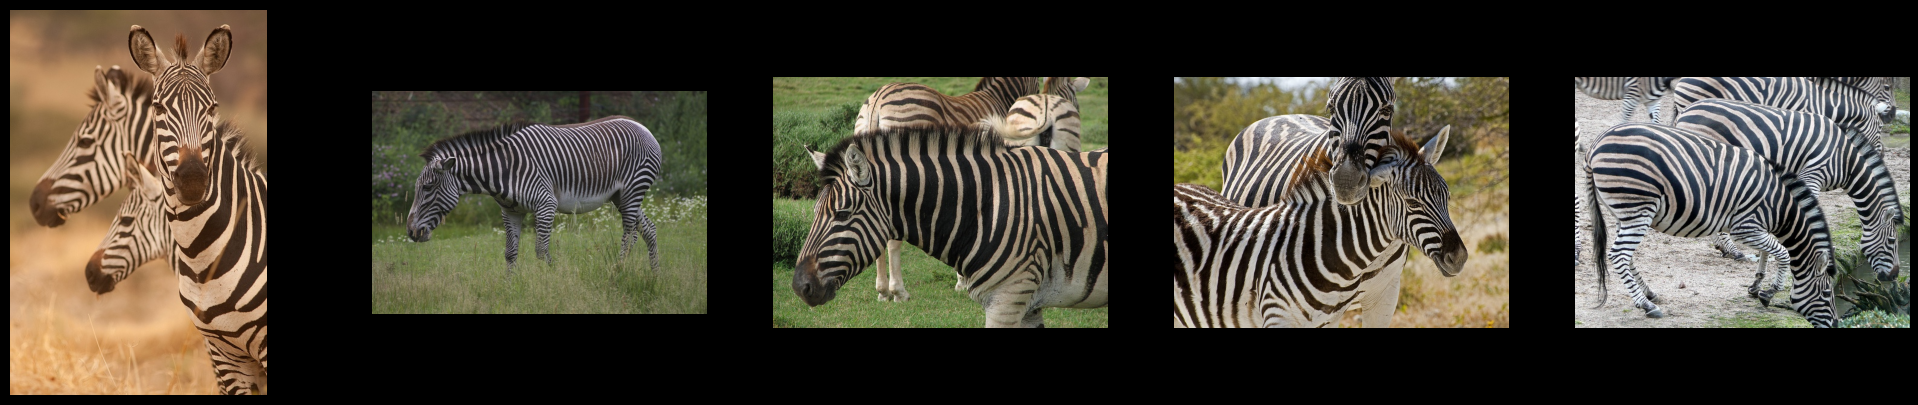

In [29]:
fig, axs = plt.subplots(1, 5, figsize = (25, 5))
axs[0].imshow(zebra_imgs[40])
axs[1].imshow(zebra_imgs[41])
axs[2].imshow(zebra_imgs[34])
axs[3].imshow(zebra_imgs[31])
axs[4].imshow(zebra_imgs[30])

axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[3].axis('off')
axs[4].axis('off')

plt.show()

Here we perform a transformation and convert the images into tensors, so that we can use them as inputs to NN model.

在这里，我们进行变换并将图像转换为张量，以便我们可以将它们用作神经网络模型的输入。

In [33]:
# Load sample images from folder
zebra_tensors = torch.stack([transform(img) for img in zebra_imgs])
experimental_set_rand

[[Concept(0, 'striped'), Concept(3, 'random_0')],
 [Concept(0, 'striped'), Concept(4, 'random_1')]]

In [13]:
# zebra class index
zebra_ind = 340


tcav_scores_w_random = mytcav.interpret(inputs=zebra_tensors,
                                        experimental_sets=experimental_set_rand,
                                        target=zebra_ind,
                                        n_steps=5,
                                       )
tcav_scores_w_random

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-3': defaultdict(None,
                         {'inception4c': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 1.3640, -1.3640])},
                          'inception4d': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 2.0858, -2.0858])},
                          'inception4e': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 1.1527, -1.1527])}}),
             '0-4': defaultdict(None,
                         {'inception4c': {'sign_count': tensor([0.9600, 0.0400]),
                           'magnitude': tensor([ 1.4900, -1.4900])},
                          'inception4d': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 2.3324, -2.3324])},
                          'inception4e': {'sign_count': tensor([1., 0.]),
                           'magnitude': 

Auxiliary functions for visualizing of TCAV scores.

用于可视化 TCAV 分数的辅助函数。

In [14]:
def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores):
    fig, ax = plt.subplots(1, len(experimental_sets), figsize = (25, 7))

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):

        concepts = experimental_sets[idx_es]
        concepts_key = concepts_to_str(concepts)

        pos = [np.arange(len(layers))]
        for i in range(1, len(concepts)):
            pos.append([(x + barWidth) for x in pos[i-1]])
        _ax = (ax[idx_es] if len(experimental_sets) > 1 else ax)
        for i in range(len(concepts)):
            val = [format_float(scores['sign_count'][i]) for layer, scores in tcav_scores[concepts_key].items()]
            _ax.bar(pos[i], val, width=barWidth, edgecolor='white', label=concepts[i].name)

        # Add xticks on the middle of the group bars
        _ax.set_xlabel('Set {}'.format(str(idx_es)), fontweight='bold', fontsize=16)
        _ax.set_xticks([r + 0.3 * barWidth for r in range(len(layers))])
        _ax.set_xticklabels(layers, fontsize=16)

        # Create legend & Show graphic
        _ax.legend(fontsize=16)

    plt.show()

Let's use above defined auxilary functions and visualize tcav scores below.

让我们使用上面定义的辅助函数，并将 tcav 分数可视化如下。

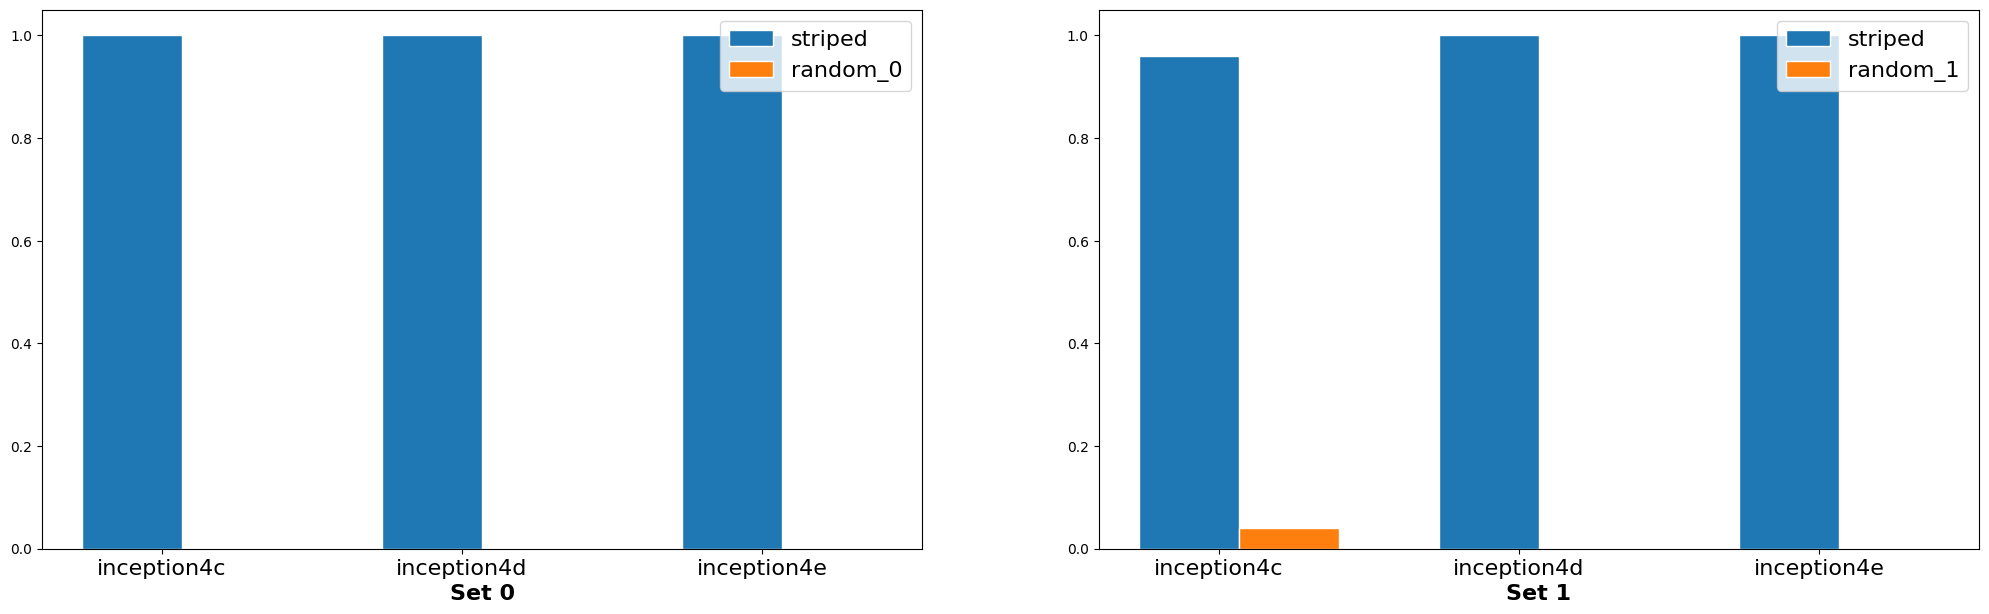

In [15]:

plot_tcav_scores(experimental_set_rand, tcav_scores_w_random)


From the plot above we observe that the images that are predicted as `zebra` by the model are very sensitive  to `striped` concept as opposed to any random concept. Note that random concepts contain a set of images that are uniformly sampled from imagenet dataset - they do not represent any specific concept.

zebra从上图可以看出，模型预测的图像对striped概念非常敏感，而非对任何随机概念都敏感。需要注意的是，随机概念包含一组从 ImageNet 数据集中均匀采样的图像——它们并不代表任何特定的概念。

Now, let's compute TCAV scores for a different experimental set that contains three different specific concepts such as `striped`, `zigzagged` and `dotted`.

striped现在，让我们计算包含三个不同特定概念（例如、zigzagged和dotted）的不同实验集的 TCAV 分数。

In [16]:
experimental_set_zig_dot = [[stripes_concept, zigzagged_concept, dotted_concept]]


In [17]:

tcav_scores_w_zig_dot = mytcav.interpret(inputs=zebra_tensors,
                                         experimental_sets=experimental_set_zig_dot,
                                         target=zebra_ind,
                                         n_steps=5)


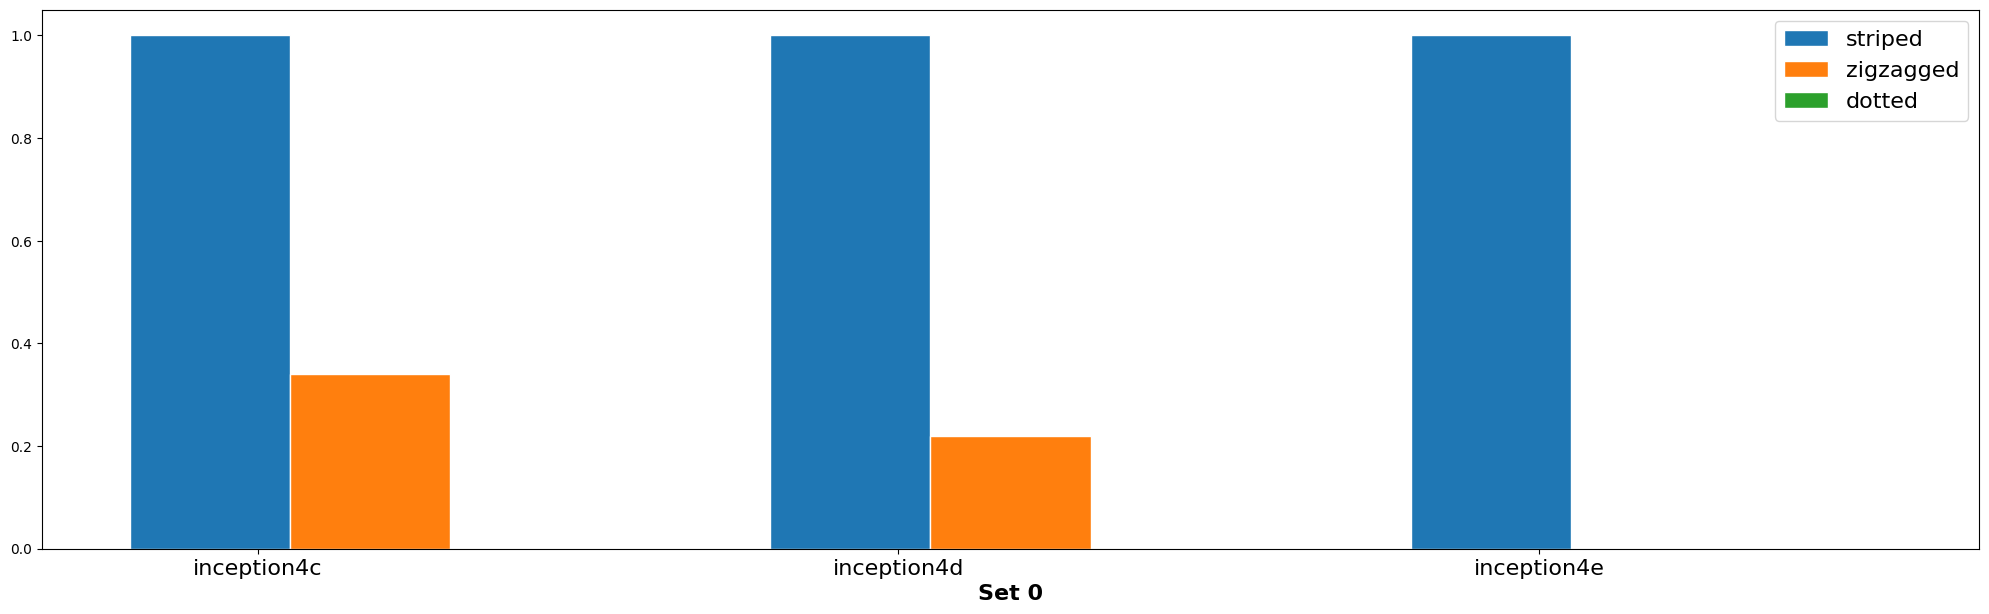

In [18]:
plot_tcav_scores(experimental_set_zig_dot, tcav_scores_w_zig_dot)    

Similar to the previous case in this experiment as well we observe that `striped` concept has very high TCAV scores across all  three layers compared to `zigzagged` and `dotted`. This means that the `striped` concept is an essential concept in predicting `zebra`.

与之前的实验类似，我们也观察到striped概念在所有三层上的 TCAV 得分都非常高，远高于zigzagged和dotted。这意味着striped概念 是预测 的关键概念zebra。

# Statistical significance testing of concepts
# 概念的统计显著性检验

In order to convince ourselves that our concepts truly explain our predictions, we conduct statistical significance tests on TCAV scores by constructing a number of experimental sets. In this case we look into the `striped` concept and a number of random concepts.
If `striped` concept is truly important in predicting `zebra` in the images that contain `zebra`, then we will see consistent high TCAV scores for `striped` concept across all experimental sets as apposed to any other concept.

Each experimental set contains a random concept consisting of a number of random subsamples. In our case this allows us to estimate the robustness of TCAV scores by the means of numerous random concepts. 

Let's define those experimental sets in the cell below.


We will look into `striped`, and a number of random concepts drawn uniformly random from imagenet dataset.
```
concept_list = ['stripped', 'ceo', 'random_0', 'random_1', 'random2', ... , 'random_n'], n is the number of concepts
```

Then, we will construct pairs of experimental sets that contain pairs of two concepts. In this case:
```
experimental_sets = [['stripped', 'random_0'], ['stripped', 'random_1'], ... , ['striped', 'random_n'], 
                    ['random_0', 'random_1'], ['random_0', 'random_2'], ... , ['random_0', 'random_n']]
```

为了验证我们提出的概念确实能够解释我们的预测，我们构建了一系列实验集，并对 TCAV 分数进行统计显著性检验。在本例中，我们考察了striped概念本身以及一些随机概念。如果概念对于预测包含该概念的图像striped结果确实至关重要，那么在所有实验集中，该概念的 TCAV 分数将始终保持在较高水平，而其他任何概念的 TCAV 分数则较低。zebrazebrastriped

每个实验集都包含一个随机概念，该随机概念由若干随机子样本组成。在我们的研究中，这使我们能够通过大量的随机概念来估计TCAV评分的稳健性。

让我们在下面的单元格中定义这些实验集。

我们将研究striped，以及从 ImageNet 数据集中均匀随机抽取的一些随机概念。
```
concept_list = ['stripped', 'ceo', 'random_0', 'random_1', 'random2', ... , 'random_n'], n is the number of concepts
```

然后，我们将构建包含两两概念的实验数据集对。在这种情况下：
```
experimental_sets = [['stripped', 'random_0'], ['stripped', 'random_1'], ... , ['striped', 'random_n'],
                    ['random_0', 'random_1'], ['random_0', 'random_2'], ... , ['random_0', 'random_n']]
```


In [19]:
n = 2

random_concepts = [assemble_concept('random_' + str(i+2), i+5) for i in range(0, n)]

print(random_concepts)

experimental_sets = [[stripes_concept, random_0_concept], [stripes_concept, random_1_concept]]
experimental_sets.extend([[stripes_concept, random_concept] for random_concept in random_concepts])

experimental_sets.append([random_0_concept, random_1_concept])
experimental_sets.extend([[random_0_concept, random_concept] for random_concept in random_concepts])

experimental_sets

[Concept(5, 'random_2'), Concept(6, 'random_3')]


[[Concept(0, 'striped'), Concept(3, 'random_0')],
 [Concept(0, 'striped'), Concept(4, 'random_1')],
 [Concept(0, 'striped'), Concept(5, 'random_2')],
 [Concept(0, 'striped'), Concept(6, 'random_3')],
 [Concept(3, 'random_0'), Concept(4, 'random_1')],
 [Concept(3, 'random_0'), Concept(5, 'random_2')],
 [Concept(3, 'random_0'), Concept(6, 'random_3')]]

Now, let's define a convenience function for assembling the experiments together as lists of Concept objects, creating and running the TCAV:

现在，让我们定义一个便捷函数，用于将实验组装成 Concept 对象列表，创建并运行 TCAV：

In [20]:
def assemble_scores(scores, experimental_sets, idx, score_layer, score_type):
    score_list = []
    for concepts in experimental_sets:
        score_list.append(scores["-".join([str(c.id) for c in concepts])][score_layer][score_type][idx])
        
    return score_list

In addition, it is interesting to look into the p-values of statistical significance tests for each concept. We say, that we reject null hypothesis, if the p-value for concept's TCAV scores is smaller than 0.05. This indicates that the concept is important for model prediction.

We label concept populations as overlapping if p-value > 0.05 otherwise disjoint.

此外，研究每个概念的统计显著性检验的p值也很有意义。如果概念的TCAV得分的p值小于0.05，我们就拒绝原假设。这表明该概念对模型预测很重要。

如果 p 值 > 0.05，则将概念群体标记为重叠；否则标记为不相交。

In [ ]:
%%sql


In [ ]:
def get_pval(scores, experimental_sets, score_layer, score_type, alpha=0.05, print_ret=False):
    
    P1 = assemble_scores(scores, experimental_sets, 0, score_layer, score_type)
    P2 = assemble_scores(scores, experimental_sets, 1, score_layer, score_type)
    
    if print_ret:
        print('P1[mean, std]: ', format_float(np.mean(P1)), format_float(np.std(P1)))
        print('P2[mean, std]: ', format_float(np.mean(P2)), format_float(np.std(P2)))

    _, pval = ttest_ind(P1, P2)

    if print_ret:
        print("p-values:", format_float(pval))

    if pval < alpha:    # alpha value is 0.05 or 5%
        relation = "Disjoint"
        if print_ret:
            print("Disjoint")
    else:
        relation = "Overlap"
        if print_ret:
            print("Overlap")
        
    return P1, P2, format_float(pval), relation


We now run the TCAV and obtain the scores:

现在我们运行 TCAV 并获得分数：

In [ ]:
# Run TCAV
scores = mytcav.interpret(zebra_tensors, experimental_sets, zebra_ind, n_steps=5)

We can present the distribution of tcav scores using boxplots and the p-values indicating whether TCAV scores of those concepts are overlapping or disjoint.

我们可以使用箱线图来表示 tcav 分数的分布，并使用 p 值来表示这些概念的 TCAV 分数是重叠的还是不相交的。

In [ ]:
n = 4
def show_boxplots(layer, metric='sign_count'):

    def format_label_text(experimental_sets):
        concept_id_list = [exp.name if i == 0 else \
                             exp.name.split('_')[0] for i, exp in enumerate(experimental_sets[0])]
        return concept_id_list

    n_plots = 2

    fig, ax = plt.subplots(1, n_plots, figsize = (25, 7 * 1))
    fs = 18
    for i in range(n_plots):
        esl = experimental_sets[i * n : (i+1) * n]
        P1, P2, pval, relation = get_pval(scores, esl, layer, metric)

        ax[i].set_ylim([0, 1])
        ax[i].set_title(layer + "-" + metric + " (pval=" + str(pval) + " - " + relation + ")", fontsize=fs)
        ax[i].boxplot([P1, P2], showfliers=True)

        ax[i].set_xticklabels(format_label_text(esl), fontsize=fs)

    plt.show()

Below box plots visualize the distribution of TCAV scores for two pairs of concepts in three different layers. Each layer is visualized in a separate jupyter cell. 
Below diagrams show that `striped` concept has TCAV scores that are consistently high across all layers and experimental sets as apposed to `random` concept. It also shows that `striped` and `random` are disjoint populations.

When we compare the populations of two random concepts we see that the p-value is much higher, meaning that those populations overlap and we cannot reject null hypothesis anymore.

下图箱线图可视化了三个不同层级中两对概念的 TCAV 得分分布。每一层都在单独的 Jupyter 单元格中可视化。下图显示，striped概念 在所有层级和实验集中都具有始终较高的 TCAV 得分，而概念 则不然random。此外，下图还显示striped和random是互不相交的群体。

当我们比较两个随机概念的总体时，我们发现 p 值要高得多，这意味着这些总体存在重叠，我们不能再拒绝零假设了。

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


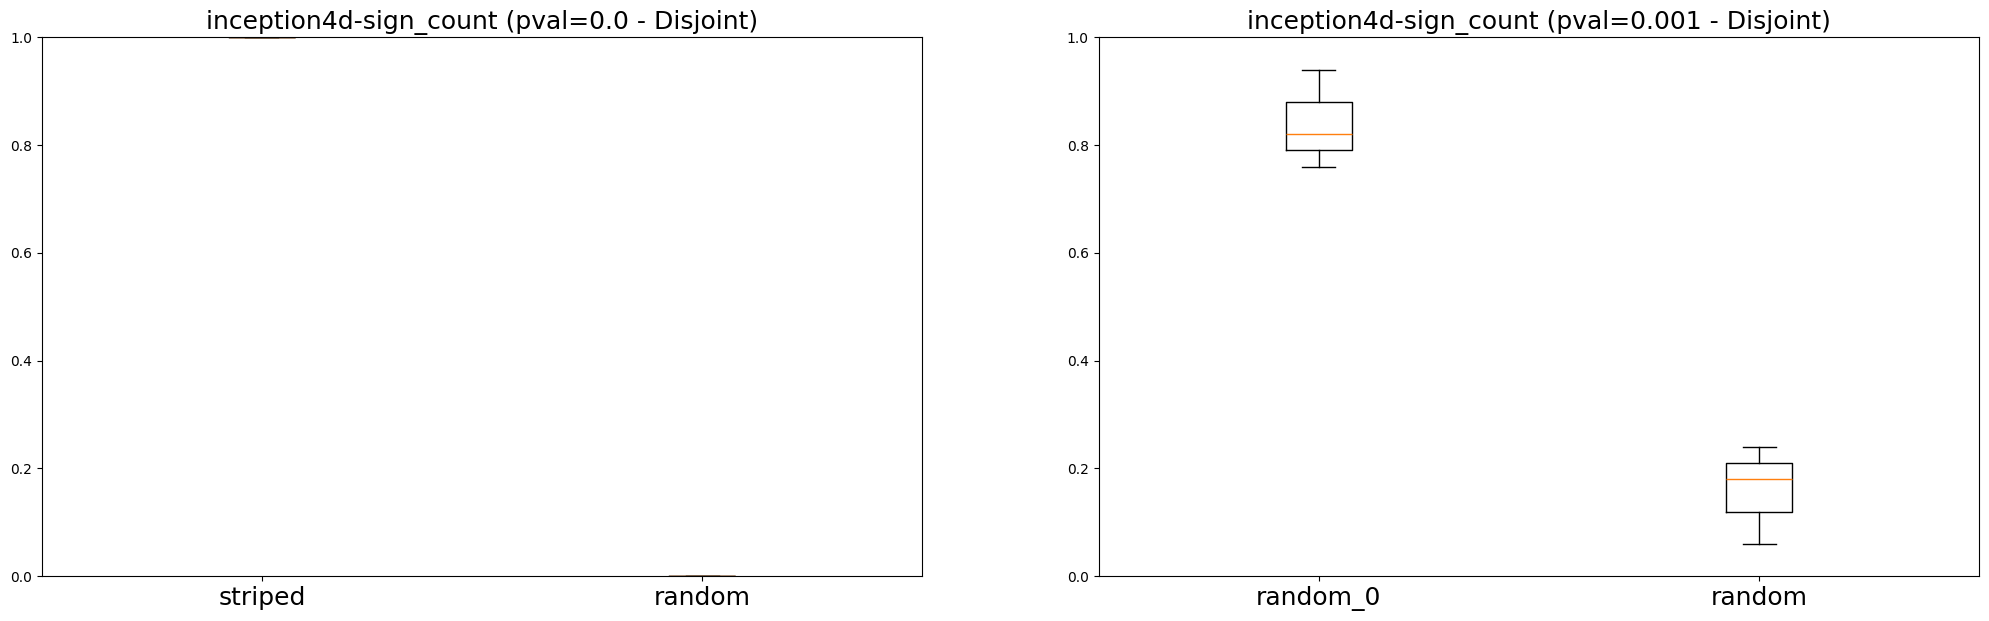

In [25]:
show_boxplots ("inception4c")

/opt/anaconda3/envs/captum_env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


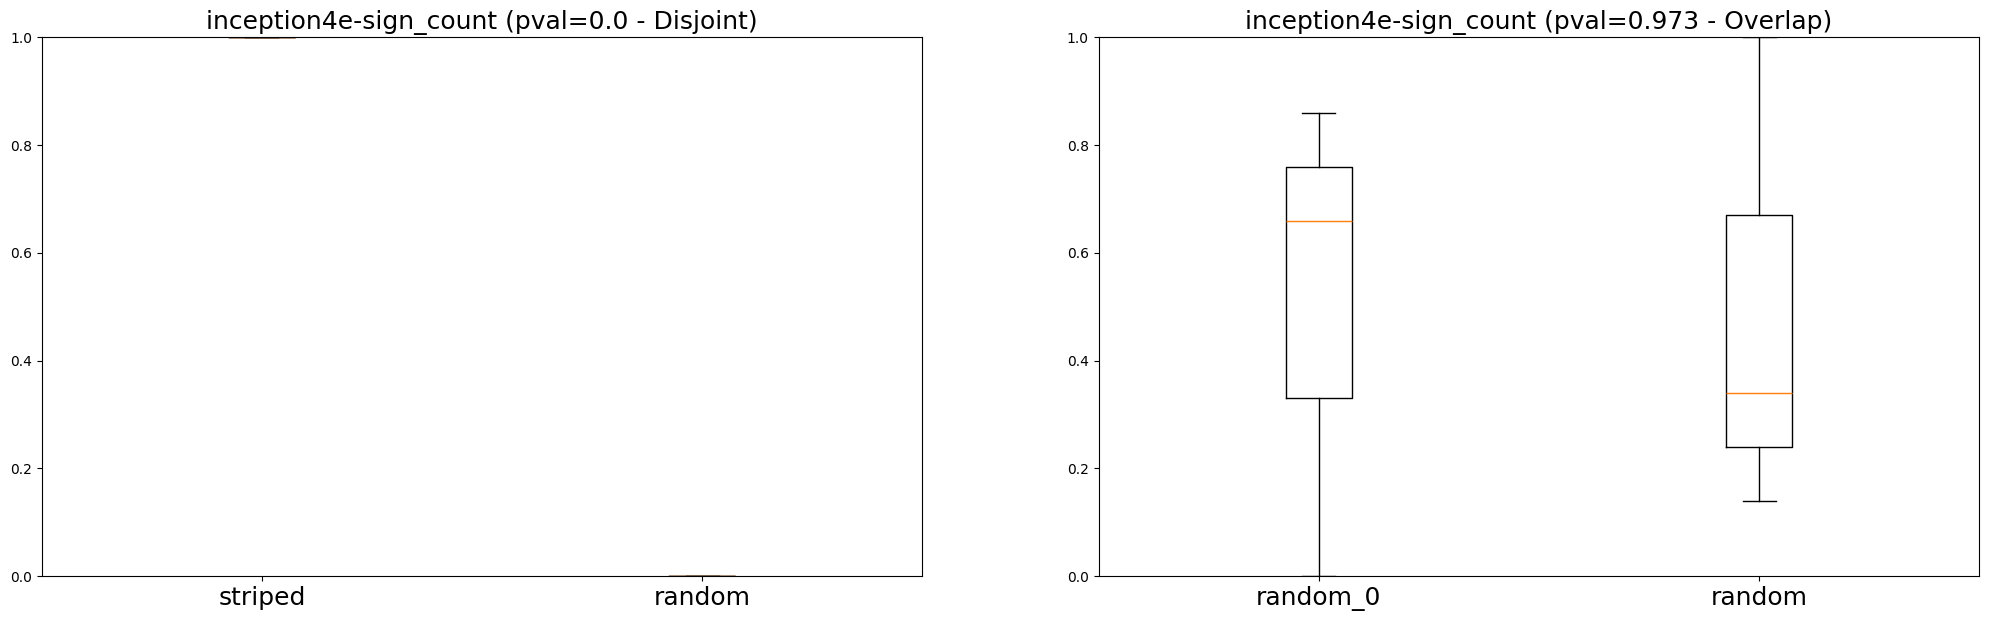

In [26]:
show_boxplots ("inception4d")

In [ ]:
show_boxplots ("inception4e")